In [6]:
import gymnasium as gym
import numpy as np
import random
import time
from collections import deque

import cv2 as cv
import matplotlib.pyplot as plt

import ale_py

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.optimizers import Adam

In [7]:
gamma = 0.99          # 할인율
eps = 1.0
eps_decay = 0.99995
eps_min = 0.01

replay_memory_siz = 20000
batch_siz = 32

copy_interval = 1000  #행위 신경망을 목표 신경망에 복사하는 주기
# n_match = 3
n_match = 500

consecutive = 4 #연속 4장 프레임으로 상태 표현
rows = 84 #신경망 입력 영상 크기
cols = 84

greedy_select = lambda x: np.random.choice(
    np.argwhere(x == np.max(x)).flatten()
)

In [8]:
env = gym.make('ALE/Breakout-v5', render_mode='rgb_array')

actions = list(range(env.action_space.n))
n_actions = len(actions)

print("Action space:", env.action_space)
print("Actions:", actions)

try:
    print("Action meanings:", env.unwrapped.get_action_meanings())
except:
    print("Action meanings 확인 불가")

Action space: Discrete(4)
Actions: [0, 1, 2, 3]
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT']


In [9]:
#DQN
def deep_network():
    cnn = Sequential()

    cnn.add(
        Conv2D(
            32,
            (5, 5),
            activation='relu',
            strides=2,
            input_shape=(rows, cols, consecutive)
        )
    )

    cnn.add(
        Conv2D(
            64,
            (3, 3),
            activation='relu',
            strides=2
        )
    )

    cnn.add(
        Conv2D(
            64,
            (3, 3),
            activation='relu',
            strides=1
        )
    )

    cnn.add(Flatten())

    cnn.add(Dense(512, activation='relu'))
    cnn.add(Dense(n_actions, activation='linear'))

    cnn.compile(
        loss='MSE',
        optimizer=Adam(learning_rate=0.00005)
    )

    return cnn

In [15]:
#화면 전처리
def preprocess(img):
    crop = img[30:200, :, :]

    gray = cv.cvtColor(crop, cv.COLOR_RGB2GRAY)

    resized = cv.resize(gray, dsize=(rows, cols))

    return resized.reshape(rows, cols, 1)

In [11]:
#DQN 모델 학습
best_avg = -999

def model_learning():
    mini_batch = random.sample(range(len(R)), batch_siz)

    s = np.asarray([R[idx][0] for idx in mini_batch], dtype=np.float32)
    a = np.asarray([R[idx][1] for idx in mini_batch], dtype=np.int32)
    r = np.asarray([R[idx][2] for idx in mini_batch], dtype=np.float32)
    s1 = np.asarray([R[idx][3] for idx in mini_batch], dtype=np.float32)
    done = np.asarray([R[idx][4] for idx in mini_batch], dtype=bool)

    X = s / 255.0
    X1 = s1 / 255.0

    Y = model_behavior.predict(X, verbose=0)
    next_q = model_target.predict(X1, verbose=0)

    for j in range(batch_siz):
        if done[j]:
            Y[j, a[j]] = r[j]
        else:
            Y[j, a[j]] = r[j] + gamma * np.max(next_q[j])

    model_behavior.train_on_batch(X, Y)


def save_best_model(i):
    global best_avg

    if len(scores) >= 20:
        avg20 = np.mean(scores[-20:])

        if avg20 > best_avg:
            best_avg = avg20
            model_behavior.save("fbreakout.keras")
            print(
                "best model 저장:",
                i + 1,
                "번째 경기 / avg20 =",
                round(best_avg, 2)
            )

In [12]:
#모델 생성
model_target = deep_network()    #목표 신경망
model_behavior = deep_network()  #행동 신경망

R = deque(maxlen=replay_memory_siz)  #리플레이 메모리 초기화

n_update = 0 #누적 프레임 수
scores = [] #경기 점수 기록

start_time_total = time.time()

C:\Users\HNW\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#트레이닝 서포트 함수
def launch(env):
    action_meanings = env.unwrapped.get_action_meanings()

    if "FIRE" in action_meanings:
        fire_action = action_meanings.index("FIRE")
    else:
        fire_action = 1

    return env.step(fire_action)


def get_lives(env, info):
    if isinstance(info, dict) and "lives" in info:
        return info["lives"]

    try:
        return env.unwrapped.ale.lives()
    except:
        return 0

In [14]:
#트레이닝 반복
for i in range(n_match):
    start = time.time()

    obs, info = env.reset()

    # 공 발사
    obs, _, terminated, truncated, info = launch(env)

    lives = get_lives(env, info)

    imem = deque(maxlen=consecutive) #4장 연속영상으로 상태 표현

    for _ in range(consecutive):
        imem.append(preprocess(obs))

    s = np.transpose(
        np.squeeze(np.asarray(imem)),
        (1, 2, 0)
    )

    score = 0

    while True:
        if np.random.random() < eps:
            a = np.random.choice(n_actions) #랜덤 선택
        else:
            y = model_behavior.predict(
                s.reshape(1, rows, cols, consecutive) / 255.0,
                verbose=0
            )[0]

            a = greedy_select(y) #탐욕 선택

        obs1, r, terminated, truncated, info = env.step(actions[a])

        #공 발사 재실행
        new_lives = get_lives(env, info)

        if new_lives < lives:
            lives = new_lives

            if not (terminated or truncated):
                obs1, r2, terminated, truncated, info = launch(env)
                r += r2

        imem.append(preprocess(obs1))

        s1 = np.transpose(
            np.squeeze(np.asarray(imem)),
            (1, 2, 0)
        )

        # 학습 / 출력용 분리
        R.append((s, a, np.sign(r), s1, terminated or truncated))

        eps = max(eps_min, eps * eps_decay) #앱실론 점차 줄임

        #너무 자주 학습하면 느리고 불안정해서 8 step마다 학습하도록 변경
        if len(R) > 1000 and n_update % 8 == 0:
            model_learning()

        n_update += 1

        if n_update % copy_interval == 0:
            model_target.set_weights(model_behavior.get_weights())

        s = s1

        # 그래프용 실제 점수
        score += r

        if terminated or truncated:
            scores.append(score)
            break

    print(
        i + 1,
        "번째 경기 점수=",
        scores[-1],
        "(",
        int(time.time() - start),
        "초 ) eps=",
        np.round(eps, 8)
    )

    # 최근 20경기 평균이 제일 좋을 때 제출용 모델 저장
    save_best_model(i)

    # 보험용 중간 저장
    if (i + 1) % 50 == 0:
        model_behavior.save("fbreakout_checkpoint.keras")
        print("checkpoint 저장:", i + 1, "번째 경기")

1 번째 경기 점수= 2.0 ( 0 초 ) eps= 0.98925784
2 번째 경기 점수= 0.0 ( 0 초 ) eps= 0.98333992
3 번째 경기 점수= 3.0 ( 0 초 ) eps= 0.97141576
4 번째 경기 점수= 3.0 ( 0 초 ) eps= 0.95968418
5 번째 경기 점수= 2.0 ( 2 초 ) eps= 0.95042001
6 번째 경기 점수= 2.0 ( 6 초 ) eps= 0.9403515
7 번째 경기 점수= 2.0 ( 6 초 ) eps= 0.93113428
8 번째 경기 점수= 2.0 ( 6 초 ) eps= 0.92209961
9 번째 경기 점수= 2.0 ( 7 초 ) eps= 0.91214866
10 번째 경기 점수= 1.0 ( 5 초 ) eps= 0.9054235
11 번째 경기 점수= 0.0 ( 5 초 ) eps= 0.9000521
12 번째 경기 점수= 0.0 ( 5 초 ) eps= 0.89475729
13 번째 경기 점수= 2.0 ( 8 초 ) eps= 0.88620851
14 번째 경기 점수= 2.0 ( 11 초 ) eps= 0.87664488
15 번째 경기 점수= 0.0 ( 8 초 ) eps= 0.87140063
16 번째 경기 점수= 1.0 ( 8 초 ) eps= 0.86501916
17 번째 경기 점수= 2.0 ( 12 초 ) eps= 0.85671166
18 번째 경기 점수= 2.0 ( 9 초 ) eps= 0.84848395
19 번째 경기 점수= 1.0 ( 8 초 ) eps= 0.84222819
20 번째 경기 점수= 0.0 ( 8 초 ) eps= 0.83723169
best model 저장: 20 번째 경기 / avg20 = 1.45
21 번째 경기 점수= 3.0 ( 10 초 ) eps= 0.82856938
best model 저장: 21 번째 경기 / avg20 = 1.5
22 번째 경기 점수= 3.0 ( 13 초 ) eps= 0.81934095
best model 저장: 22 번째 경기 / avg

In [16]:
print(
    "학습에 걸린 총 시간=",
    int(time.time() - start_time_total),
    "초"
)

model_target.save("fbreakout.keras")
env.close()

학습에 걸린 총 시간= 11492 초


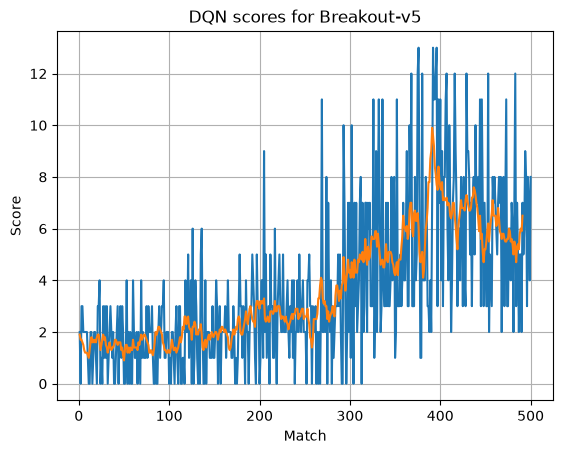

In [17]:
plt.plot(range(1, len(scores) + 1), scores)

if len(scores) >= 10:
    smooth = np.convolve(scores, 10 * [0.1], mode='valid')
    plt.plot(range(1, len(smooth) + 1), smooth)

plt.title("DQN scores for Breakout-v5")
plt.ylabel("Score")
plt.xlabel("Match")
plt.grid()
plt.show()